In [1]:
import numpy as np
import matplotlib.pyplot as plt
import os
os.chdir('/zhome/71/c/146676/main/')
import SimpleITK as sitk
import importlib
from helpers import module_auxiliary as ma
from matplotlib_scalebar.scalebar import ScaleBar
from cil.optimisation.operators import GradientOperator # For extract edge function
import matplotlib
#matplotlib.use('Agg')
from segmentation import s3_watershed_eds
importlib.reload(s3_watershed_eds)
import matplotlib.colors as mcolors
import copy
from segmentation import s2_watershed_filter

In [2]:
full_seg_, segmentation_, elem_segm_, elems_ = s3_watershed_eds.get_segmentation_from_watersheds(
    thresholds = np.array([15, 15, 15, 10 , 20, 20, 30, 12, 5 , 30, 10, 13 , 92, 15, 5]),
    output=True)
segmentation = {}
for key in segmentation_:
    if key != "labels":
        
        moving = sitk.GetImageFromArray(segmentation_[key].astype(np.float32))
        segmentation[key] = s3_watershed_eds.transform_eds(segmentation_[key].astype(np.float32))

elem_segm = {}
for key in elem_segm_:
    if key != "labels":
        
        moving = sitk.GetImageFromArray(elem_segm_[key].astype(np.float32))
        elem_segm[key] = s3_watershed_eds.transform_eds(elem_segm_[key].astype(np.float32))

elems = {}
for key in elems_:
    if key != "labels":
        
        moving = sitk.GetImageFromArray(elems_[key].astype(np.float32))
        elems[key] = s3_watershed_eds.transform_eds(elems_[key].astype(np.float32))

moving = sitk.GetImageFromArray(full_seg_)
full_seg = s3_watershed_eds.transform_eds(full_seg_)

In [3]:
def plot_segmentations(background, ground_truth_seg, test_seg = None, class_labels = None,transparencies = [0.7, 0.5]):
    #plt.close('all)')
    Ns = np.max(ground_truth_seg)
    if class_labels is not None:
        Ns = 9
    if class_labels is None:
        class_labels = "".join(map(str, range(0, Ns)))
    # Add black as the first color

    colors_d = [
        (0, 0, 255),      # Blue Plagio
        (128, 0, 128),    # Purple Alk
        (255, 50, 150),   # Pink   #cpx
        (0, 255, 0),      # Green   # opx
        (255, 165, 0),    # Orange     #apatite
        (160, 255, 0),    # Brown Ilminite
        (0, 170, 255),    # light blue, chromite
        (255, 0, 0),    #  pyrite   
        (255, 0, 255),   # Magenta, Baddelyite
        (0, 255, 255) # Cyan
    ]

    # Convert RGB to normalized values and prepend a transparent color
    colors_d = [(0, 0, 0, 0.7)] + [(r/255, g/255, b/255, 0.5) for r, g, b in colors_d[:Ns]]

    # Create the colormap
    cmap_d = mcolors.ListedColormap(colors_d)
    boundaries = np.arange(-0.5, Ns+1, 1)  # [-0.5, 0.5, 1.5, ..., 14.5]
    norm = mcolors.BoundaryNorm(boundaries, cmap_d.N)
    # Plot the matrix with the custom colormap
    fig, ax = plt.subplots(figsize=(10, 10))
    ax.imshow(background, cmap="gray", vmin = 0.01, vmax = 50)  # Adjust alpha for blending

    im = ax.imshow(ground_truth_seg, cmap=cmap_d, norm=norm)

    # Create a colorbar next to the plot
    cbar = fig.colorbar(im, ax=ax, ticks=[], fraction=0.05, pad=0.04)
    bounds = np.arange(len(colors_d) + 1)  # Define color boundaries
    # Manually add text labels next to the colorbar
    cbar_ax = cbar.ax  # Get the colorbar axis
    for i, label in enumerate(class_labels):
        y_pos = (bounds[i] + bounds[i + 1]-1) / 2  # Center text at each color
        cbar_ax.text(1.3, y_pos, label, va='center', ha='left', fontsize=12)
    cbar_ax.set_frame_on(False)  # Remove border



    # Overlay the grayscale image using transparency
    
    #ax.axis('off')
    # Add scale bar (adjust values based on real-world scale)
    scalebar = ScaleBar(6, "µm", location="lower right", color="white", scale_loc="bottom", box_alpha=0.5)
    ax.add_artist(scalebar)
    fig.savefig('/dtu-compute/msaca/cache/plot.png', dpi=200)
    plt.close('all')
    #plt.show()
    #fig.tight_layout()
    if test_seg is not None:
        temp = ground_truth_seg.copy()
        temp[test_seg.astype(bool)] = Ns+1
        colors_d = [(r, g, b, alpha) for r, g, b, alpha in colors_d] + [(1.0, 1.0, 0.0, 0.35)]
        cmap_d = mcolors.ListedColormap(colors_d)
        boundaries = np.arange(-0.5, Ns+2, 1)  # [-0.5, 0.5, 1.5, ..., 14.5]
        norm = mcolors.BoundaryNorm(boundaries, cmap_d.N)
        # Plot the matrix with the custom colormap
        fig2, ax2 = plt.subplots(figsize=(10, 10))
        ax2.imshow(background, cmap="gray", vmin = 0.01, vmax = 0.04)  # Adjust alpha for blending
        im2 = ax2.imshow(temp, cmap=cmap_d, norm=norm)

        # Create a colorbar next to the plot
        cbar = fig2.colorbar(im2, ax=ax2, ticks=[], fraction=0.05, pad=0.04)
        bounds = np.arange(len(colors_d) + 1)  # Define color boundaries
        # Manually add text labels next to the colorbar
        cbar_ax = cbar.ax  # Get the colorbar axis
        class_labels.append('Test_seg')
        for i, label in enumerate(class_labels):
            y_pos = (bounds[i] + bounds[i + 1]-1) / 2  # Center text at each color
            cbar_ax.text(1.3, y_pos, label, va='center', ha='left', fontsize=12)

        cbar_ax.set_frame_on(False)  # Remove border
        # Overlay the grayscale image using transparency
        #ax.axis('off')
        # Add scale bar (adjust values based on real-world scale)
        scalebar = ScaleBar(6, "µm", location="lower right", color="white", scale_loc="bottom", box_alpha=0.5)
        ax2.add_artist(scalebar)
        fig2.tight_layout()
        fig2.show()
        return fig, fig2

In [13]:
box = 450,1474,368,1595

y0, y1, x0, x1 = box
background = elems['Mg'][y0:y1,x0:x1]*1.0+10.0
ground_truth_seg = full_seg[y0:y1,x0:x1]
class_labels=['Background', 'Feldspar an-al', 'Feldspar al-or', 'Pyroxene (Cpx)', 'Pyroxene (Opx)', 'Apatite', 'Ilminite', 'Chromite', 'Pyrite', 'Baddelyite']
plot_segmentations(background, ground_truth_seg, test_seg = None, class_labels = class_labels,transparencies = [0, 0])

In [5]:
elems_n = copy.deepcopy(elems)
elements = ['Al', 'Ca', 'Cl', 'Cr', 'Fe',  'K', 'Mg', 'Na', 'Ni',  'O',  'P',  'S', 'Si', 'Ti', 'Zr']
sum_elems = np.zeros(np.shape(elems['Al']))
for element in elements:
    sum_elems = sum_elems + elems[element]

mask = sum_elems>10
for element in elements:
    elems_n[element] = elems_n[element].astype(np.float32)
    elems_n[element][mask] = elems[element][mask]/sum_elems[mask]
    elems_n[element][np.logical_not(mask)] = 0

In [6]:
import itertools
def extract_index_from_dict(data_dict, n, m):
    return {key: value[n, m] for key, value in data_dict.items()}
print(extract_index_from_dict(elems_n,900,1000))

def augment_features(data_dict, alpha=1e-2):
    augmented_dict = {}
    
    # Generate all pairs (x, y) where x ≠ y
    for x_key, y_key in itertools.permutations(data_dict.keys(), 2):
        augmented_key = f"{x_key}_over_{y_key}"  # New feature name
        augmented_dict[augmented_key] = (data_dict[x_key] + alpha) / (data_dict[y_key] + alpha)
    
    return augmented_dict
elems_n_a = augment_features(elems_n,alpha=1e-2)

{'Al': 0.105960265, 'Ca': 0.052980132, 'Cl': 0.0397351, 'Cr': 0.0066225166, 'Fe': 0.0066225166, 'K': 0.013245033, 'Mg': 0.026490066, 'Na': 0.0794702, 'Ni': 0.03311258, 'O': 0.23841059, 'P': 0.0066225166, 'S': 0.01986755, 'Si': 0.3576159, 'Ti': 0.013245033, 'Zr': 0.0}


In [7]:
import numpy as np

def normalize_dict(data_dict):
    """Normalizes each 2D array in the dictionary to zero mean and unit standard deviation.
    
    Returns:
        normalized_dict: Dictionary with normalized 2D arrays.
        means: Dictionary of means for each key.
        stds: Dictionary of standard deviations for each key.
    """
    means = {key: np.mean(value) for key, value in data_dict.items()}
    stds = {key: np.std(value) for key, value in data_dict.items()}
    
    normalized_dict = {key: (value - means[key]) / (stds[key] + 1e-8)  # Avoid division by zero
                       for key, value in data_dict.items()}
    
    return normalized_dict, means, stds

def denormalize_dict(normalized_dict, means, stds):
    """Reverses the normalization using stored means and standard deviations.
    
    Returns:
        denormalized_dict: Dictionary with original scale restored.
    """
    denormalized_dict = {key: (value * stds[key]) + means[key] for key, value in normalized_dict.items()}
    
    return denormalized_dict

# Example usage:
# Assuming `data_dict` is your input dictionary of 2D arrays
elems_nn, means, stds = normalize_dict(elems_n)

print(extract_index_from_dict(elems_nn,900,1000))
print(extract_index_from_dict(elems_nn,900,1040))
elems_n_a = augment_features(elems_n,alpha=1e-2)
elems_nn_a, means_a, stds_a = normalize_dict(elems_n_a)
print(extract_index_from_dict(elems_nn_a,900,1000))
print(extract_index_from_dict(elems_nn_a,900,1040))

{'Al': 2.1858711, 'Ca': 1.3798444, 'Cl': 0.8412971, 'Cr': 0.46201497, 'Fe': -0.67221844, 'K': 0.46578196, 'Mg': -0.57633597, 'Na': 2.2895594, 'Ni': 1.9844909, 'O': 1.3081799, 'P': 0.11301643, 'S': 0.60750043, 'Si': 1.2070338, 'Ti': 0.13379465, 'Zr': -0.49230304}
{'Al': 0.24925952, 'Ca': 0.49456716, 'Cl': 0.6796494, 'Cr': 0.6866257, 'Fe': 1.1212394, 'K': 0.3515622, 'Mg': 1.0669523, 'Na': 0.71676826, 'Ni': 0.5394074, 'O': 1.1991712, 'P': 0.23902039, 'S': 0.6110101, 'Si': 0.9942213, 'Ti': 0.5654246, 'Zr': -0.49230304}
{'Al_over_Ca': 0.55735606, 'Al_over_Cl': 1.2732325, 'Al_over_Cr': 2.0927157, 'Al_over_Fe': 3.8856828, 'Al_over_K': 1.9758171, 'Al_over_Mg': 2.8057735, 'Al_over_Na': 0.3081437, 'Al_over_Ni': 0.9041762, 'Al_over_O': -0.23937958, 'Al_over_P': 2.243016, 'Al_over_S': 2.0819788, 'Al_over_Si': -0.32306075, 'Al_over_Ti': 2.4466865, 'Al_over_Zr': 2.4780796, 'Ca_over_Al': -0.62391824, 'Ca_over_Cl': 0.89327174, 'Ca_over_Cr': 1.3745551, 'Ca_over_Fe': 5.412994, 'Ca_over_K': 1.3618048, 'C

In [40]:
def augment_with_region(data_dict, box=None, m_mask = None, p_samples=0.01):
    """
    Augments the flattened data by oversampling from a selected region.

    Args:
        flattened_data (ndarray): Original flattened dataset (shape: num_pixels x num_features).
        data_dict (dict): Dictionary where keys are channel names and values are 2D arrays.
        box (tuple): (x_0, x_1, y_0, y_1) defining the region to sample from.
        n_samples (int): Number of samples to draw (with replacement) from the selected region.

    Returns:
        augmented_data (ndarray): Flattened data with oversampled points appended.
    """
    n_pixels = np.sum(mask)
    n_samples = int(np.ceil(p_samples*n_pixels))
    # Extract pixels from the selected region
    if box is not None:
        x_0, x_1, y_0, y_1 = box
        selected_points = np.array([data_dict[key][x_0:x_1, y_0:y_1].flatten() for key in sorted(data_dict.keys())])
        selected_points = selected_points.T  # Shape (num_selected_pixels, num_features)
    if m_mask is not None:
        selected_points = np.array([data_dict[key][m_mask] for key in sorted(data_dict.keys())])
        selected_points = selected_points.T  # Shape (num_selected_pixels, num_features)

    # Oversample by randomly selecting points with replacement
    sampled_indices = np.random.choice(selected_points.shape[0], size=n_samples, replace=True)
    oversampled_data = selected_points[sampled_indices]

    return oversampled_data

def flatten_data(data_dict):
    data = np.array([data_dict[key][mask] for key in sorted(data_dict.keys())])
    flattened_data = data.reshape(len(data_dict), -1).T
    return flattened_data

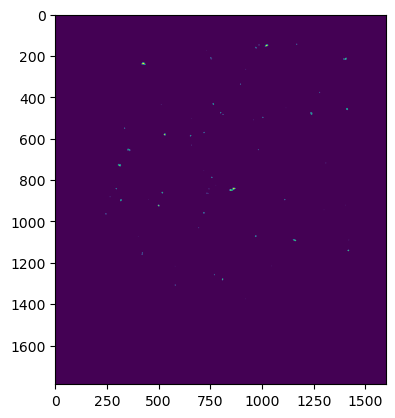

In [143]:
# Find areas, with high confidence minerals:
# Badellyite (zirconium)

## The standard thresholds: [15,   15,   15,   10 ,   20,   20,   30,  12,   5 ,   30,   10,   13 ,  92,   15,   5]
#                          ['Al', 'Ca', 'Cl', 'Cr', 'Fe',  'K', 'Mg', 'Na', 'Ni',  'O',  'P',  'S', 'Si', 'Ti', 'Zr']
#plt.imshow(elems['Mg']>60), (elems['S']<20)*(elems['Ti']<20)*(elems['Cr']<15)*
plt.imshow((elems['Si'] < 30)*1.0*(elems['Fe']>40) )
m_masks = {}
m_masks['Feld-An-Al'] = np.logical_and(elems['Al']>20,elems['Na']>20)
m_masks['Feld-Al-Or'] = np.logical_and(elems['Al']>20,elems['K']>20)
m_masks['Pyr-cpx'] = elems['Ca']>20
m_masks['Pyr-opx'] = elems['Mg']>80
m_masks['Apatite'] = elems['P']>50
m_masks['Chromite'] = elems['Cr']>50
m_masks['Ilminite'] = elems['Ti']>25
m_masks['Pyrite'] = elems['S']>20
m_masks['Zircon'] = elems['Zr']>6
m_masks['Iron_oxide'] = ((elems['Si'] < 30)*(elems['Fe']>40)).astype(bool)

In [144]:
pre_labelled_data = {}
data_flat = flatten_data(elems_nn)
box = 750,850,960,1040 # Feldspar An-Al
for key in m_masks.keys():
    pre_labelled_data[key] = augment_with_region(elems_nn, m_mask = m_masks[key], p_samples=0.01)

In [ ]:
box = 594,610,600,610 # Pyrite
flat_add2, flattened_data, add2 = augment_with_region(elems_nn, box=box, p_samples=0.01, flattened_data = flat_add1)
box = 577,590,524,537 # Ilminite
flat_add3, flattened_data, add3 = augment_with_region(elems_nn, box=box, p_samples=0.01, flattened_data = flat_add2)
box = 557,568,905,915 # Chromite
flat_add4, flattened_data, add4 = augment_with_region(elems_nn, box=box, p_samples=0.01, flattened_data = flat_add3)
box = 862,879,1015,1034 # Apatite
flat_add5, flattened_data, add5 = augment_with_region(elems_nn, box=box, p_samples=0.01, flattened_data = flat_add4)
box = 795,830,1480,1500 # Background
flat_add6, flattened_data, add6 = augment_with_region(elems_nn, box=box, p_samples=0.01, flattened_data = flat_add5)
box = 450,474,668,695 # Feldspar Al-Or
flat_add7, flattened_data, add7 = augment_with_region(elems_nn, box=box, p_samples=0.01, flattened_data = flat_add6)

In [10]:
n_components = 10

from sklearn.decomposition import PCA
from sklearn.decomposition import SparsePCA
#pca = SparsePCA(n_components=n_components,alpha=10, max_iter=50)  # Keep all 15 components
pca = PCA(n_components=n_components)  # Keep all 15 components
pca.fit(flat_add7)  # Shape (1000000, 15)
orig_transform = pca.transform(flattened_data_orig)
add1_transform = pca.transform(add1)
add2_transform = pca.transform(add2)
add3_transform = pca.transform(add3)
add4_transform = pca.transform(add4)
add5_transform = pca.transform(add5)
add6_transform = pca.transform(add6)
add7_transform = pca.transform(add7)


In [11]:
print(extract_index_from_dict(elems_nn,600,600)['S'])
print(add1[0])
elements = ['Al', 'Ca', 'Cl', 'Cr', 'Fe',  'K', 'Mg', 'Na', 'Ni',  'O',  'P',  'S', 'Si', 'Ti', 'Zr']
import pandas as pd

# Get principal components (each row corresponds to a component, each column to a feature)
principal_components = pca.components_  # Shape (15, 15)

# Convert to a DataFrame for better readability
pc_df = pd.DataFrame(principal_components, 
                     index=[f"PC{i+1}" for i in range(principal_components.shape[0])], 
                     columns=[elements[i] for i in range(principal_components.shape[1])])

# Print the principal components
pc_df = pc_df.round(2)  # Round to 3 decimal places

# Adjust display settings to show more columns
pd.set_option('display.max_columns', None)  # Show all columns
pd.set_option('display.width', 200)  # Increase width to prevent truncation
print(pc_df)

6.4914145
[ 2.7389393   1.2903975   0.24483335  0.06387032 -0.5044372   0.41867763
 -0.4818832   2.8352654   0.6246247   1.0525234  -0.110338    0.41339594
  1.3259344   0.09931947 -0.49230304]
        Al    Ca    Cl    Cr    Fe     K    Mg    Na    Ni     O     P     S    Si    Ti    Zr
PC1  -0.10  0.36  0.39  0.03 -0.05 -0.01 -0.05 -0.01  0.09 -0.06  0.81  0.09 -0.09  0.05  0.11
PC2  -0.20 -0.19  0.12  0.29  0.19  0.08  0.04  0.05  0.27 -0.03 -0.16  0.27 -0.11  0.68  0.36
PC3  -0.08  0.13 -0.16 -0.09  0.25 -0.31 -0.02 -0.28 -0.31  0.03  0.12 -0.26  0.02  0.57 -0.45
PC4  -0.43 -0.02 -0.02  0.49  0.38 -0.38  0.21 -0.23  0.00  0.05 -0.00  0.02 -0.03 -0.43  0.03
PC5   0.38  0.04 -0.07  0.69  0.11  0.37 -0.30  0.02 -0.06 -0.01  0.09  0.03 -0.01 -0.01 -0.34
PC6  -0.51 -0.08 -0.03 -0.16  0.12  0.76  0.12 -0.25 -0.10  0.01  0.06 -0.05  0.06 -0.05 -0.15
PC7  -0.08  0.08 -0.02 -0.18 -0.02 -0.11 -0.05 -0.03  0.17 -0.02 -0.07  0.81 -0.00 -0.05 -0.50
PC8   0.38  0.08 -0.09 -0.28  0.63  0.10 -0.15

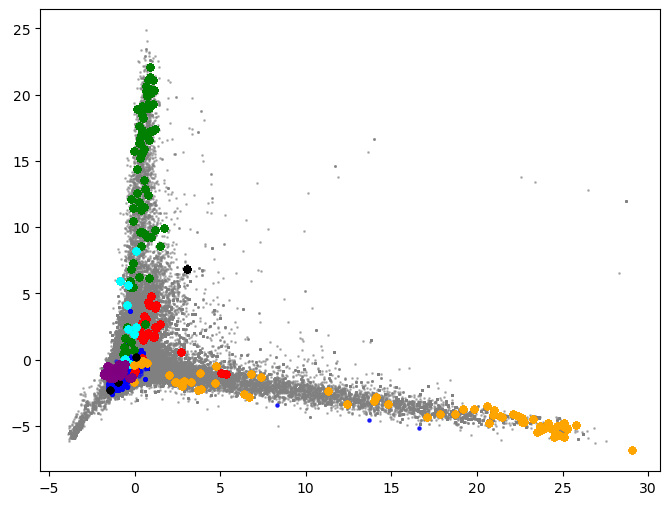

In [12]:
# Select the two largest principal components
k, j = 0,1
pc1 = orig_transform[:, k]  # First principal component
pc2 = orig_transform[:, j]  # Second principal component
fig, ax = plt.subplots(figsize=(8, 6))
scatter = ax.scatter(pc1, pc2, color='grey', s=1, alpha=0.5)
pc1 = add1_transform[:, k]  # First principal component
pc2 = add1_transform[:, j]  # Second principal component
scatter = ax.scatter(pc1, pc2, color='blue', s=5, alpha=0.5)
pc1 = add2_transform[:, k]  # First principal component
pc2 = add2_transform[:, j]  # Second principal component
scatter = ax.scatter(pc1, pc2, color='red', s=20, alpha=0.5)
pc1 = add3_transform[:, k]  # First principal component
pc2 = add3_transform[:, j]  # Second principal component
scatter = ax.scatter(pc1, pc2, color='green', s=20, alpha=0.5)
pc1 = add4_transform[:, k]  # First principal component
pc2 = add4_transform[:, j]  # Second principal component
scatter = ax.scatter(pc1, pc2, color='cyan', s=20, alpha=0.5)
pc1 = add5_transform[:, k]  # First principal component
pc2 = add5_transform[:, j]  # Second principal component
scatter = ax.scatter(pc1, pc2, color='orange', s=20, alpha=0.5)
pc1 = add6_transform[:, k]  # First principal component
pc2 = add6_transform[:, j]  # Second principal component
scatter = ax.scatter(pc1, pc2, color='black', s=20, alpha=0.5)
pc1 = add7_transform[:, k]  # First principal component
pc2 = add7_transform[:, j]  # Second principal component
scatter = ax.scatter(pc1, pc2, color='purple', s=20, alpha=0.5)




In [38]:
print(np.shape(add1_transform))

(14265, 10)


In [57]:
from sklearn.neighbors import KNeighborsClassifier

# Stack the labeled data into one dataset (X_train) and the corresponding labels (y_train)
kk = 200
X_train = np.vstack([add1_transform[:kk], add2_transform[:kk], add3_transform[:kk],
         add4_transform[:kk], add5_transform[:kk], add6_transform[:kk], add7_transform[:kk]])  # Combine all the labeled data
y_train = np.array([1] * kk + [2] * kk+ [3] * kk + 
                   [4] * kk + [5] * kk+ [6] * kk+
                   [7] * kk)  # Create corresponding labels

# Example unlabeled data (X_unlabeled) with M samples and 6 features
X_unlabeled = orig_transform

# Create a KNeighborsClassifier instance with k=3 neighbors
knn = KNeighborsClassifier(n_neighbors=10,metric='cosine')

# Fit the classifier on the labeled data
knn.fit(X_train, y_train)

# Predict the labels for the unlabeled data
y_unlabeled_pred = knn.predict(X_unlabeled)

# Output the predicted labels for the unlabeled data

In [58]:

color_map = {1: 'blue', 2: 'red', 3: 'green', 4: 'cyan', 5: 'orange', 6: 'black', 7: 'purple'}

# Get the colors for the predicted labels
colors = [color_map[label] for label in y_unlabeled_pred]


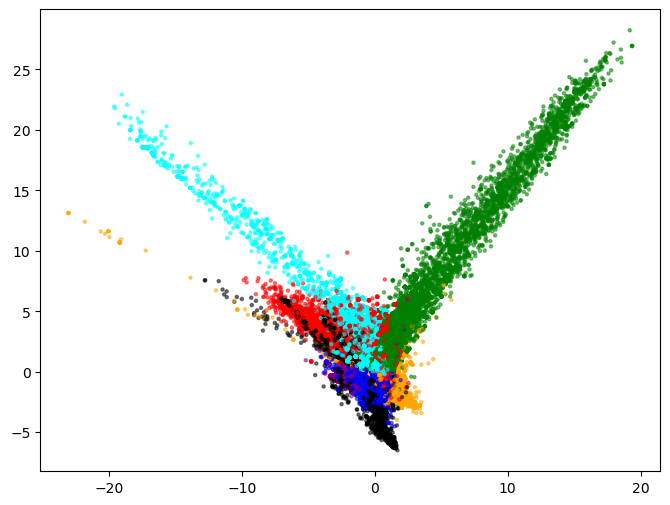

In [59]:

k,j = 2,1
# Plot the data points
plt.figure(figsize=(8, 6))
plt.scatter(X_unlabeled[:, k], X_unlabeled[:, j], c=colors, s=5, alpha=0.5)

1426446
(1426446,)
(1400,)
(1426446, 10)


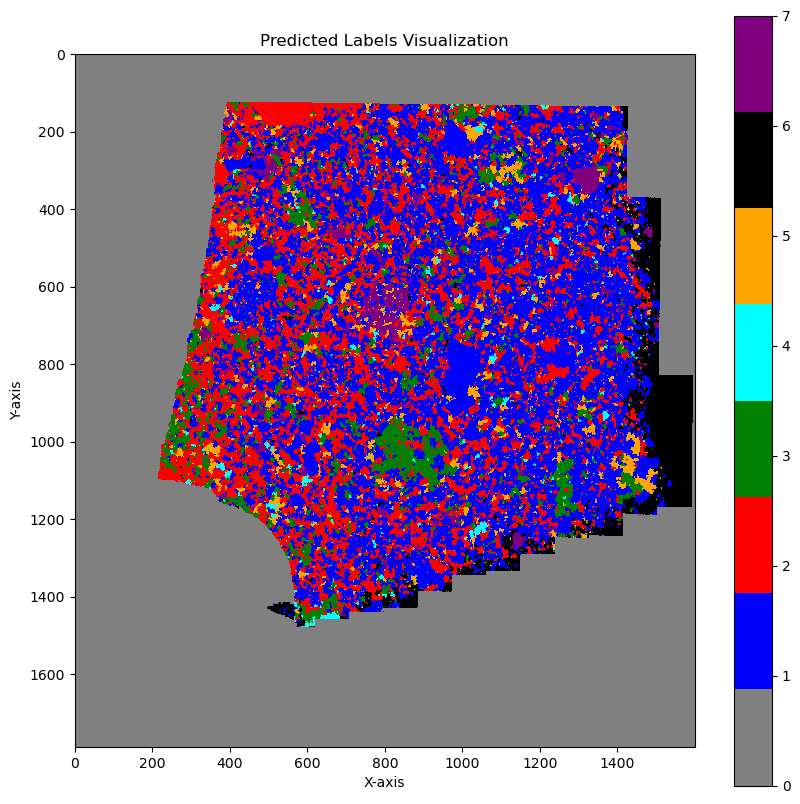

In [ ]:
from matplotlib.colors import ListedColormap

print(np.sum(mask))
print(np.shape(y_unlabeled_pred))
print(np.shape(y_train))
print(np.shape(X_unlabeled))

segmented_image = np.zeros(np.shape(mask))
segmented_image[mask] = y_unlabeled_pred

# Assuming y_unlabeled_pred_reshaped is your 2D array of predicted labels (shape: (rows, cols))
# For example, let's create a mock 2D array of predicted labels (from 0 to 5)
# Define the color map, where 0 is gray and other labels have specific colors
color_map = {0: 'gray', 1: 'blue', 2: 'red', 3: 'green', 4: 'cyan', 5: 'orange', 6: 'black', 7: 'purple'}

# Create a colormap using the color_map dictionary
colors = [color_map[i] for i in range(8)]  # Get colors for each label (0 to 5)
custom_cmap = ListedColormap(colors)

# Plot the 2D array using imshow with the custom colormap
plt.figure(figsize=(10,10))
plt.imshow(segmented_image, cmap=custom_cmap, interpolation='nearest')

# Add a colorbar to show the mapping
plt.colorbar(ticks=[0, 1, 2, 3, 4, 5,6,7])

# Set labels and title
plt.xlabel('X-axis')
plt.ylabel('Y-axis')
plt.title('Predicted Labels Visualization')

# Show the plot
plt.show()


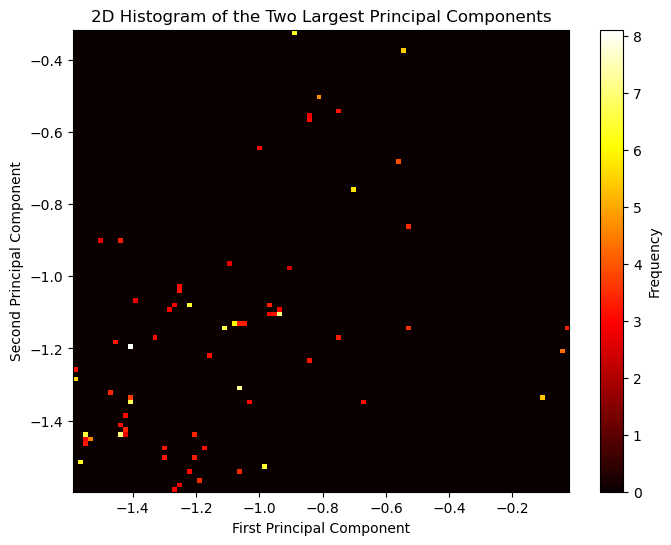

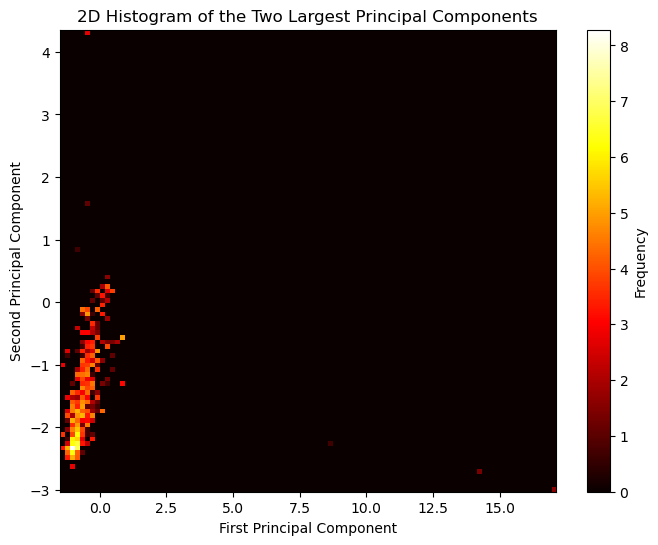

In [61]:

# Define the number of bins
num_bins = 100  # Adjust as needed

# Compute the 2D histogram
hist, x_edges, y_edges = np.histogram2d(pc1, pc2, bins=num_bins)

# Plot the heatmap
plt.figure(figsize=(8, 6))
plt.imshow(np.log(hist.T+1), origin='lower', aspect='auto', cmap='hot',
           extent=[x_edges[0], x_edges[-1], y_edges[0], y_edges[-1]])
plt.colorbar(label='Frequency')
plt.xlabel('First Principal Component')
plt.ylabel('Second Principal Component')
plt.title('2D Histogram of the Two Largest Principal Components')
plt.show()



# Select the two largest principal components
pc1 = add1_transform[:, 0]  # First principal component
pc2 = add1_transform[:, 1]  # Second principal component

# Define the number of bins
num_bins = 100  # Adjust as needed

# Compute the 2D histogram
hist, x_edges, y_edges = np.histogram2d(pc1, pc2, bins=num_bins)

# Plot the heatmap
plt.figure(figsize=(8, 6))
plt.imshow(np.log(hist.T+1), origin='lower', aspect='auto', cmap='hot',
           extent=[x_edges[0], x_edges[-1], y_edges[0], y_edges[-1]])
plt.colorbar(label='Frequency')
plt.xlabel('First Principal Component')
plt.ylabel('Second Principal Component')
plt.title('2D Histogram of the Two Largest Principal Components')
plt.show()